# ver3 CNN Baseline - Alzheimer MRI Classification

이 노트북은 BiomedCLIP cache 실험과 비교하기 위한 CNN baseline입니다.

목표:
- BiomedCLIP ver2 결과와 CNN fine-tuning 결과를 공정하게 비교한다.
- separate augmentation 전략은 유지한다.
- 같은 원본 이미지에서 나온 augmented samples가 train/val에 섞이지 않도록 base image 단위 group-aware split을 적용한다.
- test set에는 augmentation을 절대 적용하지 않는다.

기본 모델은 `EfficientNet-B0`입니다. config에서 `resnet50`, `densenet121`로 바꿔 비교할 수 있습니다.

## 1. 환경 점검 및 랜덤 Seed 고정

In [1]:
import os
import sys
import time
import random
from pathlib import Path
from collections import Counter
from contextlib import contextmanager

import numpy as np
import torch

SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Python executable : {sys.executable}")
print(f"Python version    : {sys.version}")
print(f"torch version     : {torch.__version__}")
print(f"torch.version.cuda: {torch.version.cuda}")
print(f"cuda available    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name          : {torch.cuda.get_device_name(0)}")
else:
    print("GPU name          : CUDA GPU not available")
print(f"device            : {device}")

Python executable : C:\Users\user\anaconda3\envs\alzheimer\python.exe
Python version    : 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
torch version     : 2.12.0.dev20260408+cu128
torch.version.cuda: 12.8
cuda available    : True
GPU name          : NVIDIA GeForce RTX 5070
device            : cuda


## 2. Config 및 경로 설정

In [2]:
# Windows 경로 문제를 피하려고 raw string(r"...")을 사용합니다.
TRAIN_DIR = Path(r"C:\Users\user\Desktop\alzheimer_dataset\Data\train")
TEST_DIR = Path(r"C:\Users\user\Desktop\alzheimer_dataset\Data\test")

CLASS_NAMES = ["NonDemented", "VeryMildDemented", "MildDemented", "ModerateDemented"]
CLASS_KR = ["정상", "매우 경미한 치매", "경도 치매", "중등도 치매"]
NUM_CLASSES = len(CLASS_NAMES)

# CNN baseline config
# 가능한 값: "efficientnet_b0", "resnet50", "densenet121"
CNN_MODEL_NAME = "efficientnet_b0"
USE_PRETRAINED = True

# BiomedCLIP ver2와 비교하기 위해 같은 separate augmentation mode를 기본값으로 둡니다.
# 가능한 값: "original", "sepaug_3n", "sepaug_4n"
TRAIN_AUG_MODE = "sepaug_4n"
assert TRAIN_AUG_MODE in {"original", "sepaug_3n", "sepaug_4n"}

# Separate augmentation 강도
ROTATION_DEGREES = 10
SHIFT_TRANSLATE = (0.05, 0.05)
ZOOM_SCALE = (0.9, 1.1)
DETERMINISTIC_AUGMENTATION = True

# Train config
VAL_FRACTION = 0.15
BATCH_SIZE = 32
NUM_WORKERS = 0  # Windows/Jupyter에서는 0, 2, 4를 비교해 보세요.
PIN_MEMORY = True
PERSISTENT_WORKERS = NUM_WORKERS > 0
EPOCHS = 15
LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_BACKBONE = 1e-5
WEIGHT_DECAY = 1e-4
FREEZE_BACKBONE_EPOCHS = 3
USE_AMP = True

# imbalance 보정. ver2에서 안정적이었던 sqrt class weight를 기본값으로 사용합니다.
# 가능한 값: "none", "class_weight_sqrt", "class_weight_inverse"
BALANCE_STRATEGY = "class_weight_sqrt"

MAX_TRAIN_PER_CLASS = None
MAX_TEST_PER_CLASS = None

for required_dir in [TRAIN_DIR, TEST_DIR]:
    assert required_dir.exists(), f"Directory not found: {required_dir}"

print(f"TRAIN_DIR: {TRAIN_DIR}")
print(f"TEST_DIR : {TEST_DIR}")
print(f"CNN_MODEL_NAME: {CNN_MODEL_NAME}")
print(f"USE_PRETRAINED: {USE_PRETRAINED}")
print(f"TRAIN_AUG_MODE: {TRAIN_AUG_MODE}")
print(f"BALANCE_STRATEGY: {BALANCE_STRATEGY}")

TRAIN_DIR: C:\Users\user\Desktop\alzheimer_dataset\Data\train
TEST_DIR : C:\Users\user\Desktop\alzheimer_dataset\Data\test
CNN_MODEL_NAME: efficientnet_b0
USE_PRETRAINED: True
TRAIN_AUG_MODE: sepaug_4n
BALANCE_STRATEGY: class_weight_sqrt


## 3. CNN 모델 및 Preprocess 정의

`USE_PRETRAINED=True`이면 torchvision pretrained weight를 사용합니다. 최초 실행 시 weight 다운로드가 필요할 수 있습니다.

In [3]:
import torch.nn as nn
from torchvision import models

def build_cnn_model(model_name: str, num_classes: int, use_pretrained: bool = True):
    model_name = model_name.lower()

    if model_name == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT if use_pretrained else None
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        preprocess = weights.transforms() if weights is not None else models.EfficientNet_B0_Weights.DEFAULT.transforms()

    elif model_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT if use_pretrained else None
        model = models.resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        preprocess = weights.transforms() if weights is not None else models.ResNet50_Weights.DEFAULT.transforms()

    elif model_name == "densenet121":
        weights = models.DenseNet121_Weights.DEFAULT if use_pretrained else None
        model = models.densenet121(weights=weights)
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)
        preprocess = weights.transforms() if weights is not None else models.DenseNet121_Weights.DEFAULT.transforms()

    else:
        raise ValueError(f"Unknown CNN_MODEL_NAME: {model_name}")

    return model, preprocess

model, preprocess = build_cnn_model(CNN_MODEL_NAME, NUM_CLASSES, USE_PRETRAINED)
model = model.to(device)
print(model.__class__.__name__)
print(f"model device: {next(model.parameters()).device}")
print(preprocess)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\user/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 63.4MB/s]


EfficientNet
model device: cuda:0
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


## 4. Dataset 정의: 원본 / Separate Augmentation

In [4]:
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

@contextmanager
def temporary_seed(seed: int):
    python_state = random.getstate()
    numpy_state = np.random.get_state()
    torch_state = torch.random.get_rng_state()
    cuda_states = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    try:
        random.seed(seed)
        np.random.seed(seed % (2**32 - 1))
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        yield
    finally:
        random.setstate(python_state)
        np.random.set_state(numpy_state)
        torch.random.set_rng_state(torch_state)
        if cuda_states is not None:
            torch.cuda.set_rng_state_all(cuda_states)

def collect_base_samples(root_dir: Path, class_names, max_per_class=None):
    samples = []
    for label_idx, class_name in enumerate(class_names):
        class_dir = Path(root_dir) / class_name
        if not class_dir.exists():
            print(f"[WARN] 클래스 폴더가 없습니다: {class_dir}")
            continue
        image_paths = sorted(
            p for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        )
        if max_per_class is not None:
            image_paths = image_paths[:max_per_class]
        for image_path in image_paths:
            samples.append((image_path, label_idx))
    return samples

class MRIDataset(Dataset):
    # augmentation 없이 원본 이미지만 사용하는 dataset입니다.
    def __init__(self, samples, preprocess):
        self.samples = list(samples)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert("RGB")
        image = self.preprocess(image)
        return image, torch.tensor(label, dtype=torch.long)

class SeparateAugmentedMRIDataset(Dataset):
    # 각 원본 이미지에 rotation, shift, zoom을 독립적으로 적용합니다.
    # include_original=False이면 3N, include_original=True이면 4N dataset입니다.
    # combined augmentation은 사용하지 않습니다.
    def __init__(
        self,
        samples,
        preprocess,
        include_original: bool = False,
        deterministic: bool = True,
        seed: int = 42,
        rotation_degrees: float = 10,
        shift_translate=(0.05, 0.05),
        zoom_scale=(0.9, 1.1),
    ):
        self.base_samples = list(samples)
        self.preprocess = preprocess
        self.include_original = include_original
        self.deterministic = deterministic
        self.seed = seed
        self.output_types = ["rotation", "shift", "zoom"]
        if include_original:
            self.output_types = ["original"] + self.output_types

        self.rotation_transform = transforms.RandomRotation(degrees=rotation_degrees)
        self.shift_transform = transforms.RandomAffine(degrees=0, translate=shift_translate)
        self.zoom_transform = transforms.RandomAffine(degrees=0, scale=zoom_scale)

    def __len__(self):
        return len(self.base_samples) * len(self.output_types)

    def _apply_augmentation(self, image, aug_type):
        if aug_type == "original":
            return image
        if aug_type == "rotation":
            return self.rotation_transform(image)
        if aug_type == "shift":
            return self.shift_transform(image)
        if aug_type == "zoom":
            return self.zoom_transform(image)
        raise ValueError(f"Unknown augmentation type: {aug_type}")

    def __getitem__(self, idx):
        aug_type_count = len(self.output_types)
        base_idx = idx // aug_type_count
        aug_type_idx = idx % aug_type_count
        aug_type = self.output_types[aug_type_idx]

        image_path, label = self.base_samples[base_idx]
        image = Image.open(image_path).convert("RGB")

        if self.deterministic:
            aug_seed = self.seed + base_idx * 1009 + aug_type_idx * 9176
            with temporary_seed(aug_seed):
                image = self._apply_augmentation(image, aug_type)
        else:
            image = self._apply_augmentation(image, aug_type)

        image = self.preprocess(image)
        return image, torch.tensor(label, dtype=torch.long)

## 5. Group-Aware Train/Validation Split

같은 원본 이미지의 augmented samples가 train과 validation에 동시에 들어가면 validation 누수가 생길 수 있습니다. 따라서 base image 단위로 split한 뒤 train base samples에만 augmentation을 적용합니다.

In [5]:
from sklearn.model_selection import train_test_split

train_base_samples_all = collect_base_samples(TRAIN_DIR, CLASS_NAMES, MAX_TRAIN_PER_CLASS)
test_base_samples = collect_base_samples(TEST_DIR, CLASS_NAMES, MAX_TEST_PER_CLASS)

base_labels = np.array([label for _, label in train_base_samples_all])
base_indices = np.arange(len(train_base_samples_all))

train_base_indices, val_base_indices = train_test_split(
    base_indices,
    test_size=VAL_FRACTION,
    random_state=SEED,
    stratify=base_labels,
)

train_base_samples = [train_base_samples_all[i] for i in train_base_indices]
val_base_samples = [train_base_samples_all[i] for i in val_base_indices]

if TRAIN_AUG_MODE == "original":
    train_dataset = MRIDataset(train_base_samples, preprocess)
    expected_multiplier = 1.0
elif TRAIN_AUG_MODE == "sepaug_3n":
    train_dataset = SeparateAugmentedMRIDataset(
        train_base_samples,
        preprocess=preprocess,
        include_original=False,
        deterministic=DETERMINISTIC_AUGMENTATION,
        seed=SEED,
        rotation_degrees=ROTATION_DEGREES,
        shift_translate=SHIFT_TRANSLATE,
        zoom_scale=ZOOM_SCALE,
    )
    expected_multiplier = 3.0
elif TRAIN_AUG_MODE == "sepaug_4n":
    train_dataset = SeparateAugmentedMRIDataset(
        train_base_samples,
        preprocess=preprocess,
        include_original=True,
        deterministic=DETERMINISTIC_AUGMENTATION,
        seed=SEED,
        rotation_degrees=ROTATION_DEGREES,
        shift_translate=SHIFT_TRANSLATE,
        zoom_scale=ZOOM_SCALE,
    )
    expected_multiplier = 4.0
else:
    raise ValueError(f"Unknown TRAIN_AUG_MODE: {TRAIN_AUG_MODE}")

val_dataset = MRIDataset(val_base_samples, preprocess)
test_dataset = MRIDataset(test_base_samples, preprocess)

print(f"원본 train 이미지 수: {len(train_base_samples_all):,}")
print(f"base train/val split: {len(train_base_samples):,} / {len(val_base_samples):,}")
print(f"TRAIN_AUG_MODE: {TRAIN_AUG_MODE}")
print(f"실제 train dataset 길이: {len(train_dataset):,}")
print(f"예상 배수: {expected_multiplier:.1f}x")
print(f"실제 배수: {len(train_dataset) / max(len(train_base_samples), 1):.1f}x")
print(f"val 이미지 수: {len(val_dataset):,}")
print(f"test 이미지 수: {len(test_dataset):,}")

print("\n[Base train 클래스별 이미지 수]")
base_train_counts = Counter(label for _, label in train_base_samples)
for idx, name in enumerate(CLASS_NAMES):
    print(f"{name:20s}: {base_train_counts.get(idx, 0):,}")

print("\n[Validation 클래스별 이미지 수]")
val_counts = Counter(label for _, label in val_base_samples)
for idx, name in enumerate(CLASS_NAMES):
    print(f"{name:20s}: {val_counts.get(idx, 0):,}")

원본 train 이미지 수: 69,148
base train/val split: 58,775 / 10,373
TRAIN_AUG_MODE: sepaug_4n
실제 train dataset 길이: 235,100
예상 배수: 4.0x
실제 배수: 4.0x
val 이미지 수: 10,373
test 이미지 수: 17,289

[Base train 클래스별 이미지 수]
NonDemented         : 45,710
VeryMildDemented    : 9,333
MildDemented        : 3,401
ModerateDemented    : 331

[Validation 클래스별 이미지 수]
NonDemented         : 8,067
VeryMildDemented    : 1,647
MildDemented        : 600
ModerateDemented    : 59


## 6. DataLoader 생성 및 속도 측정

In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    sampler=None,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    sampler=None,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    sampler=None,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)

def benchmark_dataloader(loader, max_batches=50, warn_below_images_per_sec=80):
    start = time.perf_counter()
    total_images = 0
    batches = 0
    for batches, (images, labels) in enumerate(loader, start=1):
        total_images += images.size(0)
        if batches >= max_batches:
            break
    elapsed = time.perf_counter() - start
    images_per_sec = total_images / max(elapsed, 1e-9)
    print(f"{batches:,}개 batch에서 {total_images:,}장 이미지를 {elapsed:.2f}초 동안 읽었습니다.")
    print(f"DataLoader 처리량: {images_per_sec:.1f} images/s")
    if images_per_sec < warn_below_images_per_sec:
        print("[WARN] DataLoader가 느립니다. NUM_WORKERS, batch_size, augmentation 비용을 비교하세요.")
    return images_per_sec

print(f"train_loader batch_size={BATCH_SIZE}, shuffle=True, sampler=None")
print(f"num_workers={NUM_WORKERS}, pin_memory={PIN_MEMORY}, persistent_workers={PERSISTENT_WORKERS}")
train_loader_ips = benchmark_dataloader(train_loader, max_batches=50)

train_loader batch_size=32, shuffle=True, sampler=None
num_workers=0, pin_memory=True, persistent_workers=False
50개 batch에서 1,600장 이미지를 9.05초 동안 읽었습니다.
DataLoader 처리량: 176.8 images/s


## 7. 1 Batch GPU Forward 테스트

In [7]:
images, labels = next(iter(train_loader))
images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

print(f"images device: {images.device}")
print(f"model device : {next(model.parameters()).device}")

model.eval()
if torch.cuda.is_available():
    torch.cuda.synchronize()
start = time.perf_counter()
with torch.inference_mode():
    logits = model(images)
if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start

print(f"1 batch size : {images.size(0)}")
print(f"logits shape : {tuple(logits.shape)}")
print(f"forward time : {elapsed:.4f}s")
print(f"forward speed: {images.size(0) / max(elapsed, 1e-9):.1f} images/s")

images device: cuda:0
model device : cuda:0
1 batch size : 32
logits shape : (32, 4)
forward time : 19.1825s
forward speed: 1.7 images/s


## 8. Loss, Optimizer, Freeze 설정

In [8]:
def make_normalized_class_weight(class_counts, mode: str, device):
    counts = np.maximum(np.asarray(class_counts, dtype=np.float64), 1.0)
    if mode == "class_weight_sqrt":
        weights = 1.0 / np.sqrt(counts)
    elif mode == "class_weight_inverse":
        weights = 1.0 / counts
    elif mode == "none":
        return None
    else:
        raise ValueError(f"Unknown BALANCE_STRATEGY: {mode}")
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=device)

train_base_labels = np.array([label for _, label in train_base_samples])
train_class_counts = np.bincount(train_base_labels, minlength=NUM_CLASSES)
class_weight = make_normalized_class_weight(train_class_counts, BALANCE_STRATEGY, device)

if class_weight is not None:
    criterion = nn.CrossEntropyLoss(weight=class_weight)
    print(f"class_weight: {[round(x, 4) for x in class_weight.detach().cpu().tolist()]}")
else:
    criterion = nn.CrossEntropyLoss()
    print("class_weight: None")

def set_backbone_trainable(model, model_name: str, trainable: bool):
    for param in model.parameters():
        param.requires_grad = trainable

    # classifier는 항상 학습합니다.
    if model_name == "efficientnet_b0":
        for param in model.classifier.parameters():
            param.requires_grad = True
    elif model_name == "resnet50":
        for param in model.fc.parameters():
            param.requires_grad = True
    elif model_name == "densenet121":
        for param in model.classifier.parameters():
            param.requires_grad = True

def make_optimizer(model, model_name: str):
    head_params = []
    backbone_params = []

    if model_name == "efficientnet_b0":
        head_param_ids = {id(p) for p in model.classifier.parameters()}
    elif model_name == "resnet50":
        head_param_ids = {id(p) for p in model.fc.parameters()}
    elif model_name == "densenet121":
        head_param_ids = {id(p) for p in model.classifier.parameters()}
    else:
        raise ValueError(model_name)

    for p in model.parameters():
        if not p.requires_grad:
            continue
        if id(p) in head_param_ids:
            head_params.append(p)
        else:
            backbone_params.append(p)

    param_groups = []
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": LEARNING_RATE_BACKBONE})
    if head_params:
        param_groups.append({"params": head_params, "lr": LEARNING_RATE_HEAD})
    return torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)

set_backbone_trainable(model, CNN_MODEL_NAME, trainable=False)
optimizer = make_optimizer(model, CNN_MODEL_NAME)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"FREEZE_BACKBONE_EPOCHS: {FREEZE_BACKBONE_EPOCHS}")
print(f"LEARNING_RATE_HEAD: {LEARNING_RATE_HEAD}")
print(f"LEARNING_RATE_BACKBONE: {LEARNING_RATE_BACKBONE}")
print(f"학습 가능한 parameter 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

class_weight: [0.2147, 0.4751, 0.7871, 2.523]
FREEZE_BACKBONE_EPOCHS: 3
LEARNING_RATE_HEAD: 0.001
LEARNING_RATE_BACKBONE: 1e-05
학습 가능한 parameter 수: 5,124


## 9. CNN 학습

In [9]:
rrl zzfrom sklearn.metrics import accuracy_score, f1_score

scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and torch.cuda.is_available()))

def run_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    correct = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(USE_AMP and torch.cuda.is_available())):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / max(total, 1), correct / max(total, 1)

def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    y_true = []
    y_pred = []

    with torch.inference_mode():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=(USE_AMP and torch.cuda.is_available())):
                logits = model(images)
                loss = criterion(logits, labels)
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * labels.size(0)
            total += labels.size(0)
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    avg_loss = total_loss / max(total, 1)
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    return avg_loss, acc, macro_f1, weighted_f1, y_true, y_pred

history = []
best_val_macro_f1 = -1.0
best_state = None

print("CNN 학습 시작")
for epoch in range(1, EPOCHS + 1):
    if epoch == FREEZE_BACKBONE_EPOCHS + 1:
        print("Backbone unfreeze: 마지막 단계부터 전체 CNN을 낮은 learning rate로 fine-tuning합니다.")
        set_backbone_trainable(model, CNN_MODEL_NAME, trainable=True)
        optimizer = make_optimizer(model, CNN_MODEL_NAME)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(EPOCHS - epoch + 1, 1))
        print(f"학습 가능한 parameter 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    train_loss, train_acc = run_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_macro_f1, val_weighted_f1, _, _ = evaluate_model(model, val_loader, criterion, device)
    test_loss, test_acc, test_macro_f1, test_weighted_f1, _, _ = evaluate_model(model, test_loader, criterion, device)
    scheduler.step()

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1,
        "test_acc": test_acc,
        "test_macro_f1": test_macro_f1,
        "test_weighted_f1": test_weighted_f1,
    })

    lr_values = [group["lr"] for group in optimizer.param_groups]
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val acc {val_acc:.4f} macroF1 {val_macro_f1:.4f} | "
        f"test acc {test_acc:.4f} macroF1 {test_macro_f1:.4f} | "
        f"lr {lr_values}"
    )

if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(device)
    print(f"Best validation macro F1: {best_val_macro_f1:.4f}")

CNN 학습 시작
Epoch 01/15 | train loss 0.8468 acc 0.7454 | val acc 0.7602 macroF1 0.5117 | test acc 0.7657 macroF1 0.5100 | lr [0.0009890738003669028]
Epoch 02/15 | train loss 0.8123 acc 0.7472 | val acc 0.7806 macroF1 0.4999 | test acc 0.7808 macroF1 0.4827 | lr [0.0009567727288213003]
Epoch 03/15 | train loss 0.8092 acc 0.7478 | val acc 0.7864 macroF1 0.5189 | test acc 0.7879 macroF1 0.5125 | lr [0.0009045084971874737]
Backbone unfreeze: 마지막 단계부터 전체 CNN을 낮은 learning rate로 fine-tuning합니다.
학습 가능한 parameter 수: 4,012,672
Epoch 04/15 | train loss 0.5705 acc 0.8072 | val acc 0.8953 macroF1 0.8159 | test acc 0.8968 macroF1 0.8204 | lr [9.829629131445342e-06, 0.0009829629131445341]
Epoch 05/15 | train loss 0.2989 acc 0.8923 | val acc 0.9625 macroF1 0.9448 | test acc 0.9662 macroF1 0.9523 | lr [9.330127018922195e-06, 0.0009330127018922195]
Epoch 06/15 | train loss 0.1617 acc 0.9424 | val acc 0.9825 macroF1 0.9804 | test acc 0.9832 macroF1 0.9776 | lr [8.535533905932739e-06, 0.0008535533905932737]

## 10. 최종 평가

Model: efficientnet_b0
TRAIN_AUG_MODE: sepaug_4n
BALANCE_STRATEGY: class_weight_sqrt
Accuracy   : 0.9994
Macro F1   : 0.9993
Weighted F1: 0.9994

Classification report
                  precision    recall  f1-score   support

     NonDemented     0.9996    0.9996    0.9996     13445
VeryMildDemented     0.9989    0.9982    0.9985      2745
    MildDemented     0.9980    1.0000    0.9990      1001
ModerateDemented     1.0000    1.0000    1.0000        98

        accuracy                         0.9994     17289
       macro avg     0.9991    0.9995    0.9993     17289
    weighted avg     0.9994    0.9994    0.9994     17289

클래스별 accuracy
NonDemented         : 0.9996 (13440/13445)
VeryMildDemented    : 0.9982 (2740/2745)
MildDemented        : 1.0000 (1001/1001)
ModerateDemented    : 1.0000 (98/98)


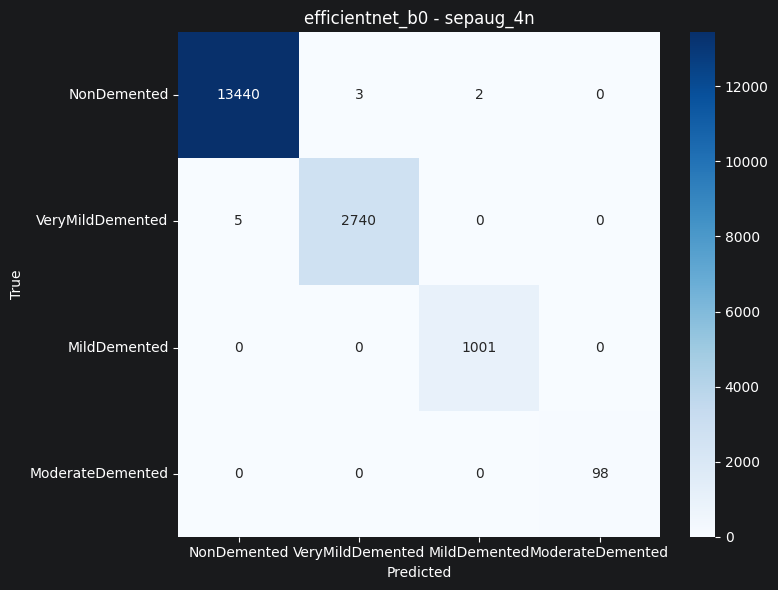

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

_, test_acc, test_macro_f1, test_weighted_f1, y_true, y_pred = evaluate_model(model, test_loader, criterion, device)
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

print(f"Model: {CNN_MODEL_NAME}")
print(f"TRAIN_AUG_MODE: {TRAIN_AUG_MODE}")
print(f"BALANCE_STRATEGY: {BALANCE_STRATEGY}")
print(f"Accuracy   : {test_acc:.4f}")
print(f"Macro F1   : {test_macro_f1:.4f}")
print(f"Weighted F1: {test_weighted_f1:.4f}")
print("\nClassification report")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

print("클래스별 accuracy")
for idx, class_name in enumerate(CLASS_NAMES):
    denom = cm[idx].sum()
    class_acc = cm[idx, idx] / denom if denom > 0 else 0.0
    print(f"{class_name:20s}: {class_acc:.4f} ({cm[idx, idx]}/{denom})")

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"{CNN_MODEL_NAME} - {TRAIN_AUG_MODE}")
plt.tight_layout()
plt.show()

## 11. 학습 곡선

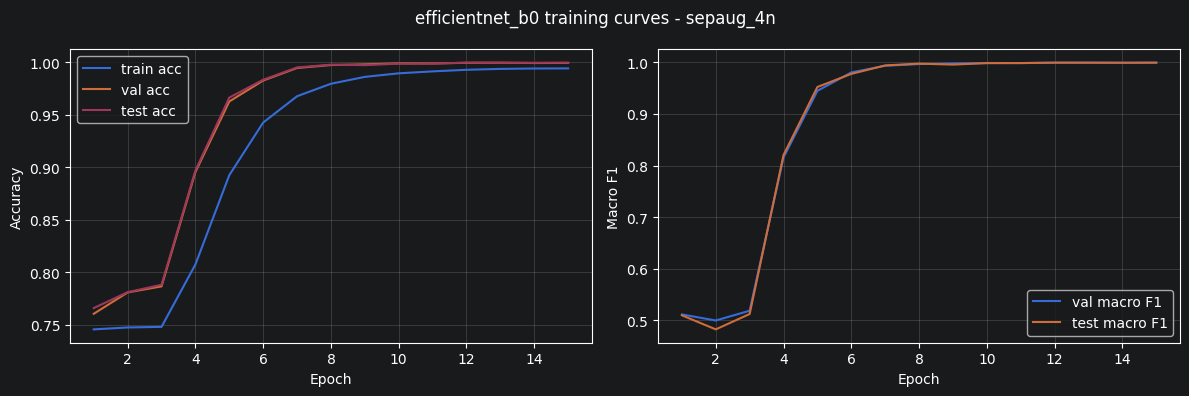

In [11]:
if history:
    epochs = [row["epoch"] for row in history]
    train_accs = [row["train_acc"] for row in history]
    val_accs = [row["val_acc"] for row in history]
    test_accs = [row["test_acc"] for row in history]
    val_macro_f1s = [row["val_macro_f1"] for row in history]
    test_macro_f1s = [row["test_macro_f1"] for row in history]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, train_accs, label="train acc")
    axes[0].plot(epochs, val_accs, label="val acc")
    axes[0].plot(epochs, test_accs, label="test acc")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, val_macro_f1s, label="val macro F1")
    axes[1].plot(epochs, test_macro_f1s, label="test macro F1")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Macro F1")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"{CNN_MODEL_NAME} training curves - {TRAIN_AUG_MODE}")
    plt.tight_layout()
    plt.show()
else:
    print("history가 비어 있습니다. 학습 셀을 먼저 실행하세요.")